<a href="https://colab.research.google.com/github/jhagihara/Hockey-Predictions/blob/main/hockey_goals_scored.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Loading Data

In [ ]:
import pandas as pd
url = 'https://nuhuskies.com/sports/womens-ice-hockey/stats/2023-24/connecticut/boxscore/12666'
nu_wih = pd.read_html(url)
len(nu_wih)

14

In [ ]:
!pip install scikit-learn>=1.0

In [ ]:
# Now to build a big loop for all the games
opponents = ['penn-state', 'penn-state', 'liu', 'liu',
             'boston-university', 'boston-university', 'merrimack',
             'st-cloud-state', 'sacred-heart', 'holy-cross', 'holy-cross',
             'connecticut', 'connecticut', 'providence', 'providence',
             'vermont', 'boston-college', 'providence', 'boston-university',
             'yale', 'holy-cross', 'maine', 'maine', 'harvard', 'new-hampshire',
             'boston-university', 'merrimack', 'merrimack', 'new-hampshire',
             'new-hampshire', 'connecticut', 'maine', 'boston-college',
             'boston-college', 'vermont', 'vermont', 'merrimack', 'new-hampshire',
             'connecticut', 'penn-state', 'penn-state', 'quinnipiac', 'quinnipiac',
             'boston-university', 'boston-university', 'holy-cross', 'holy-cross']

game_numbers = [12650, 12653, 12654, 12655, 12656, 12657, 12658,
                12660, 12662, 12663, 12664, 12665, 12666, 12668,
                12671, 12673, 12675, 12677, 12678, 12679, 12680,
                12681, 12682, 12683, 12684, 12685, 12686, 12687,
                12688, 12689, 12690, 12691, 12692, 12693, 12694,
                12695, 13051, 13103, 13104, 13184, 13185, 13186,
                13187, 13188, 13189, 13190, 13191]


In [ ]:
# Nested dictionary
from datetime import timedelta
from collections import defaultdict
full_dict = defaultdict(dict)

# The Loop
for idx in range(len(game_numbers)):
    year = "2024-25" if game_numbers[idx] > 13104 else "2023-24"
    url = f'https://nuhuskies.com/sports/womens-ice-hockey/stats/{year}/{opponents[idx]}/boxscore/{game_numbers[idx]}'
    nu_wih = pd.read_html(url)

    # Initialize a dictionary with lists as default values (though lists are not needed here)
    test_dict = defaultdict(list)

    # Clean up the team names by removing "Winner " from the "Team" column in nu_wih[0]
    nu_wih[0].iloc[:, 0] = nu_wih[0].iloc[:, 0].str.replace("Winner  ", "")

    # Assign home and visit teams to the dictionary
    test_dict['home_team'] = nu_wih[0].loc[1, "Team"]
    test_dict['visit_team'] = nu_wih[0].loc[0, "Team"]

    # Extract linescores for home and visit teams
    home_linescore = nu_wih[0].iloc[1, 1:-1]
    visit_linescore = nu_wih[0].iloc[0, 1:-1]

    # Assign home linescore values to the dictionary
    for col in home_linescore.index:
        col2 = "home_" + col  # Create a key like "home_1st", "home_2nd", etc.
        test_dict[col2] = home_linescore[col]  # Direct assignment

    # Assign visit linescore values to the dictionary
    for col in visit_linescore.index:
        col2 = "visit_" + col  # Create a key like "visit_1st", "visit_2nd", etc.
        test_dict[col2] = visit_linescore[col]  # Direct assignment

    # Function to convert the time string (e.g., "02:30") into a timedelta object
    def convert_to_timedelta(time_str):
        minutes, seconds = map(int, time_str.split(':'))
        return timedelta(minutes=minutes, seconds=seconds)

    # Function to format timedelta as "MM:SS"
    def format_timedelta(td):
        total_seconds = int(td.total_seconds())
        minutes, seconds = divmod(total_seconds, 60)
        return f"{minutes:02}:{seconds:02}"

    # Process home team's power play stats by period from nu_wih[3]
    df_home = nu_wih[3].iloc[:-1, :]  # Exclude last row

    if 'Prd' in df_home.columns:
        for period in df_home['Prd'].unique():
            i = int(period[0])  # Extract the period number (e.g., 1st -> 1)

            # Filter the data for the specific period
            period_df = df_home[df_home['Prd'] == period]

            # Sum shots, opp-shots, and calculate total elapsed power play time
            shots_sum = period_df['Shots'].sum()
            opp_shots_sum = period_df['Opp-Shots'].sum()
            total_elapsed = sum(period_df['Elapsed'].apply(convert_to_timedelta), timedelta())
            total_elapsed_str = format_timedelta(total_elapsed)

            # Store the calculated values in the dictionary
            test_dict[f'home_pp_elapsed_{i}'] = total_elapsed_str
            test_dict[f'home_pp_shots_{i}'] = shots_sum
            test_dict[f'home_pp_oppshots_{i}'] = opp_shots_sum
    else:
        test_dict[f'home_pp_elapsed_{i}'] = '00:00'
        test_dict[f'home_pp_shots_{i}'] = 0
        test_dict[f'home_pp_oppshots_{i}'] = 0

    # Process visit team's power play stats by period from nu_wih[2]
    df_visit = nu_wih[2].iloc[:-1, :]  # Exclude last row

    if 'Prd' in df_visit.columns:
        for period in df_visit['Prd'].unique():
            i = int(period[0])  # Extract the period number

            # Filter the data for the specific period
            period_df = df_visit[df_visit['Prd'] == period]

            # Sum shots, opp-shots, and calculate total elapsed power play time
            shots_sum = period_df['Shots'].sum()
            opp_shots_sum = period_df['Opp-Shots'].sum()
            total_elapsed = sum(period_df['Elapsed'].apply(convert_to_timedelta), timedelta())
            total_elapsed_str = format_timedelta(total_elapsed)

            # Store the calculated values in the dictionary
            test_dict[f'visit_pp_elapsed_{i}'] = total_elapsed_str
            test_dict[f'visit_pp_shots_{i}'] = shots_sum
            test_dict[f'visit_pp_oppshots_{i}'] = opp_shots_sum
    else:
        test_dict[f'visit_pp_elapsed_{i}'] = '00:00'
        test_dict[f'visit_pp_shots_{i}'] = 0
        test_dict[f'visit_pp_oppshots_{i}'] = 0
    # Process home team performance data from nu_wih[6]
    df_home_perf = nu_wih[6].iloc[-1, :]  # Last row

    # Keep relevant columns ('A', 'Shots By Period', 'BLK')
    columns_to_keep = df_home_perf.loc[df_home_perf.index.get_level_values(0).isin(['A', 'Shots By Period', 'BLK'])]

    # Store home team performance data in the dictionary
    for col in columns_to_keep.index:
        if col[0] == 'Shots By Period':
            test_dict[f"home_shots_p{col[1]}"] = columns_to_keep[col]
        else:
            test_dict[f'home_{col[0]}'] = columns_to_keep[col]

    # Process visit team performance data from nu_wih[5]
    df_visit_perf = nu_wih[5].iloc[-1, :]  # Last row

    # Keep relevant columns ('A', 'Shots By Period', 'BLK')
    columns_to_keep = df_visit_perf.loc[df_visit_perf.index.get_level_values(0).isin(['A', 'Shots By Period', 'BLK'])]

    # Store visit team performance data in the dictionary
    for col in columns_to_keep.index:
        if col[0] == 'Shots By Period':
            test_dict[f"visit_shots_p{col[1]}"] = columns_to_keep[col]
        else:
            test_dict[f'visit_{col[0]}'] = columns_to_keep[col]

    # Store faceoff wins for home and visit teams
    test_dict['home_faceoff_w'] = nu_wih[9].iloc[-1, -1]  # Last row, last column
    test_dict['visit_faceoff_w'] = nu_wih[9].iloc[-1, -2]  # Last row, second-to-last column

    print(f'Index {idx} worked, moving to {idx+1}')
    full_dict[f'game_{idx}'] = test_dict

Index 0 worked, moving to 1
Index 1 worked, moving to 2
Index 2 worked, moving to 3
Index 3 worked, moving to 4
Index 4 worked, moving to 5
Index 5 worked, moving to 6
Index 6 worked, moving to 7
Index 7 worked, moving to 8
Index 8 worked, moving to 9
Index 9 worked, moving to 10
Index 10 worked, moving to 11
Index 11 worked, moving to 12
Index 12 worked, moving to 13
Index 13 worked, moving to 14
Index 14 worked, moving to 15
Index 15 worked, moving to 16
Index 16 worked, moving to 17
Index 17 worked, moving to 18
Index 18 worked, moving to 19
Index 19 worked, moving to 20
Index 20 worked, moving to 21
Index 21 worked, moving to 22
Index 22 worked, moving to 23
Index 23 worked, moving to 24
Index 24 worked, moving to 25
Index 25 worked, moving to 26
Index 26 worked, moving to 27
Index 27 worked, moving to 28
Index 28 worked, moving to 29
Index 29 worked, moving to 30
Index 30 worked, moving to 31
Index 31 worked, moving to 32
Index 32 worked, moving to 33
Index 33 worked, moving to 34

#Initial Observations and Feature Engineering

In [ ]:
# Convert the nested dictionary into a DataFrame
df_2023_24 = pd.DataFrame.from_dict(full_dict, orient='index')

# Adding the latest game of the 2425 season
df_2023_24.loc[len(df_2023_24)] = ['Northeastern', 'Quinnipiac',
                                   2, 0, 2, 1, 0, 1,
                                   02.14, 3, 0, 00.00, 0, 0, 00.00, 0, 0,
                                   00.22, 1, 0, 02.00, 5, 0, 03.50, 7, 0,
                                   6, 8, 7, 9, 14, 4, 10, 11, 14, 10, 30, 28,
                                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
df_2023_24.loc[len(df_2023_24)] = ['Northeastern', 'Quinnipiac',
                                   0, 0, 0, 0, 2, 1,
                                   04.00, 2, 0, 01.47, 1, 0, 00.00, 0, 0,
                                   00.00, 0, 0, 01.47, 0, 0, 00.38, 1, 0,
                                   0, 8, 9, 11, 17, 5, 8, 11, 7, 9, 25, 36,
                                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

df_2023_24.loc[len(df_2023_24)] = ['Northeastern', 'Boston University',
                                   1, 2, 1, 0, 0, 0,
                                   02.00, 1, 0, 02.00, 2, 0, 02.00, 2, 0,
                                   00.20, 2, 0, 02.00, 0, 0, 02.00, 7, 0,
                                   7, 10, 8, 8, 9, 0, 8, 7, 11, 11, 26, 32,
                                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

# Display the DataFrame
df_2023_24.head()

# Checking if the last row in the dataframe was added correctly
last_row = df_2023_24.tail(1)
print(last_row)

       home_team         visit_team  home_1  home_2  home_3  visit_1  visit_2  \
49  Northeastern  Boston University       1       2       1        0        0   

    visit_3 home_pp_elapsed_1  home_pp_shots_1  ...  visit_OT 1  \
49        0               2.0              1.0  ...         0.0   

   visit_pp_elapsed_4  visit_pp_shots_4  visit_pp_oppshots_4 home_shots_p4  \
49                  0               0.0                  0.0           0.0   

    visit_shots_p4  home_OT 2 visit_OT 2  home_shots_p5  visit_shots_p5  
49             0.0        0.0        0.0            0.0             0.0  

[1 rows x 49 columns]


In [ ]:
df_2023_24.columns

Index(['home_team', 'visit_team', 'home_1', 'home_2', 'home_3', 'visit_1',
       'visit_2', 'visit_3', 'home_pp_elapsed_1', 'home_pp_shots_1',
       'home_pp_oppshots_1', 'home_pp_elapsed_2', 'home_pp_shots_2',
       'home_pp_oppshots_2', 'home_pp_elapsed_3', 'home_pp_shots_3',
       'home_pp_oppshots_3', 'visit_pp_elapsed_1', 'visit_pp_shots_1',
       'visit_pp_oppshots_1', 'visit_pp_elapsed_2', 'visit_pp_shots_2',
       'visit_pp_oppshots_2', 'visit_pp_elapsed_3', 'visit_pp_shots_3',
       'visit_pp_oppshots_3', 'home_A', 'home_shots_p1', 'home_shots_p2',
       'home_shots_p3', 'home_BLK', 'visit_A', 'visit_shots_p1',
       'visit_shots_p2', 'visit_shots_p3', 'visit_BLK', 'home_faceoff_w',
       'visit_faceoff_w', 'home_OT 1', 'visit_OT 1', 'visit_pp_elapsed_4',
       'visit_pp_shots_4', 'visit_pp_oppshots_4', 'home_shots_p4',
       'visit_shots_p4', 'home_OT 2', 'visit_OT 2', 'home_shots_p5',
       'visit_shots_p5'],
      dtype='object')

In [ ]:
import numpy as np

# make a list of all entries for home_team and visit_team
home_teams = df_2023_24['home_team'].unique()
visit_teams = df_2023_24['visit_team'].unique()
all_teams = np.concatenate((home_teams, visit_teams))

In [ ]:
# Need to first get the final score:
home_score = df_2023_24.home_1 + df_2023_24.home_2 + df_2023_24.home_3 + df_2023_24['home_OT 1'].fillna(0) + df_2023_24['home_OT 2'].fillna(0)
# create new column for total home score
df_2023_24['home_score'] = home_score
visit_score = df_2023_24.visit_1 + df_2023_24.visit_2 + df_2023_24.visit_3 + df_2023_24['visit_OT 1'].fillna(0) + df_2023_24['visit_OT 2'].fillna(0)
# create new column for total visit score
df_2023_24['visit_score'] = visit_score
home_team_W = (home_score > visit_score).astype(int)
home_team_W

,0
game_0,1
game_1,0
game_2,0
game_3,0
game_4,0
game_5,1
game_6,1
game_7,0
game_8,0
game_9,0


In [ ]:
# Check some intuitive features and compare their values in wins vs losses
import numpy as np
Choose_stat = 'home_pp_shots_1' # for example, home_pp_shots_1

Win_rows = home_team_W == 1
Loss_rows = home_team_W == 0
Stat_mean_wins = df_2023_24.loc[Win_rows,Choose_stat].mean()
Stat_mean_losses = df_2023_24.loc[Loss_rows,Choose_stat].mean()
Stat_diff_standard_error = np.sqrt((df_2023_24.loc[Win_rows,Choose_stat].var()/sum(Win_rows)) + (df_2023_24.loc[Loss_rows,Choose_stat].var()/sum(Loss_rows)))
if np.abs((Stat_mean_wins - Stat_mean_losses)/Stat_diff_standard_error) > 3:
    Big_diff = 'a BIG'
else:
    Big_diff = 'not that big a'

print(f'The mean value for {Choose_stat} in wins: {Stat_mean_wins} \nThe mean value for {Choose_stat} in losses: {Stat_mean_losses} \nThis is {Big_diff} difference')

The mean value for home_pp_shots_1 in wins: 1.8666666666666667 
The mean value for home_pp_shots_1 in losses: 3.0 
This is not that big a difference


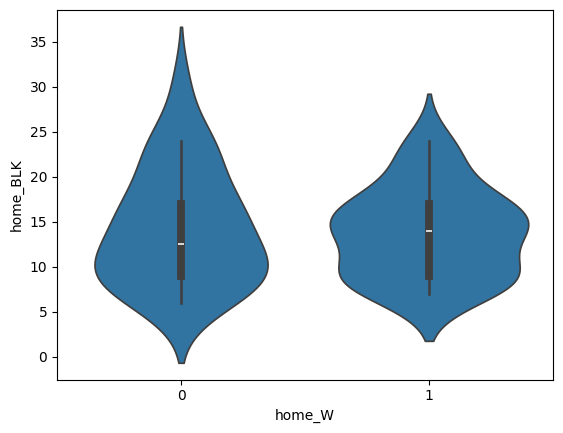

In [ ]:
# Can also make some plots
import seaborn as sns

# add the win column to the data
df_new = df_2023_24
df_new['home_W'] = home_team_W
sns.violinplot(data=df_new, x="home_W", y="home_BLK");

In [ ]:
df_new.isna().sum()

,0
home_team,0
visit_team,0
home_1,0
home_2,0
home_3,0
visit_1,0
visit_2,0
visit_3,0
home_pp_elapsed_1,18
home_pp_shots_1,18


In [ ]:
#impute all missing values with 0
df_new = df_new.fillna(0)
df_new.isna().sum()

,0
home_team,0
visit_team,0
home_1,0
home_2,0
home_3,0
visit_1,0
visit_2,0
visit_3,0
home_pp_elapsed_1,0
home_pp_shots_1,0


In [ ]:
df_new.duplicated().sum()

0

In [ ]:
df_new.columns

Index(['home_team', 'visit_team', 'home_1', 'home_2', 'home_3', 'visit_1',
       'visit_2', 'visit_3', 'home_pp_elapsed_1', 'home_pp_shots_1',
       'home_pp_oppshots_1', 'home_pp_elapsed_2', 'home_pp_shots_2',
       'home_pp_oppshots_2', 'home_pp_elapsed_3', 'home_pp_shots_3',
       'home_pp_oppshots_3', 'visit_pp_elapsed_1', 'visit_pp_shots_1',
       'visit_pp_oppshots_1', 'visit_pp_elapsed_2', 'visit_pp_shots_2',
       'visit_pp_oppshots_2', 'visit_pp_elapsed_3', 'visit_pp_shots_3',
       'visit_pp_oppshots_3', 'home_A', 'home_shots_p1', 'home_shots_p2',
       'home_shots_p3', 'home_BLK', 'visit_A', 'visit_shots_p1',
       'visit_shots_p2', 'visit_shots_p3', 'visit_BLK', 'home_faceoff_w',
       'visit_faceoff_w', 'home_OT 1', 'visit_OT 1', 'visit_pp_elapsed_4',
       'visit_pp_shots_4', 'visit_pp_oppshots_4', 'home_shots_p4',
       'visit_shots_p4', 'home_OT 2', 'visit_OT 2', 'home_shots_p5',
       'visit_shots_p5', 'home_score', 'visit_score', 'home_W'],
      dtype='o

In [ ]:
# make new column "saves"
df_new['home_saves_1'] = df_new['home_shots_p1'] - df_new['home_1']
df_new['home_saves_2'] = df_new['home_shots_p2'] - df_new['home_2']
df_new['home_saves_3'] = df_new['home_shots_p3'] - df_new['home_3']
df_new['visit_saves_1'] = df_new['visit_shots_p1'] - df_new['visit_1']
df_new['visit_saves_2'] = df_new['visit_shots_p2'] - df_new['visit_2']
df_new['visit_saves_3'] = df_new['visit_shots_p3'] - df_new['visit_3']

In [ ]:
import pandas as pd  # import pandas

# Convert all pp_elapsed columns to total seconds
for column in df_new.columns:
    if 'pp_elapsed' in column:
        # Convert to timedelta first
        df_new[column] = pd.to_timedelta(df_new[column], errors='coerce')
        # Then extract total seconds
        df_new[column] = df_new[column].dt.total_seconds()

In [ ]:
# calculates the point differential for home and away
for i in range(3):
  df_new['home_plus_minus'] = df_new['home_' + str(i+1)] - df_new['visit_' + str(i+1)]
  df_new['visit_plus_minus'] = df_new['visit_' + str(i+1)] - df_new['home_' + str(i+1)]
# List of all home columns
new_cols_home = df_new.columns[df_new.columns.str.startswith('home')].tolist()
# List of all visit columns
new_cols_visit = df_new.columns[df_new.columns.str.startswith('visit')].tolist()
# list of all
pred_cols = new_cols_visit + new_cols_home

In [ ]:
# impute missing values again
df_new = df_new.fillna(0)

#Data Preparation

In [ ]:
# getting dummy variables for df_new
df_dummies = pd.get_dummies(df_new, columns=['home_team', 'visit_team'])

In [ ]:
#train test split
from sklearn.model_selection import train_test_split
X = df_dummies.drop(columns=['home_score'])
y = df_dummies['home_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
# checking the size of x_train and x_test
print(X_train.shape)
print(X_test.shape)

(40, 87)
(10, 87)


In [ ]:
# standardizing x train and x test

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# convert back to dataframes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
"""
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
"""

'\nfrom sklearn.preprocessing import MinMaxScaler\nscaler = MinMaxScaler()\nX_train_scaled = scaler.fit_transform(X_train)\nX_test_scaled = scaler.transform(X_test)\n'

In [ ]:
# Function to compute adjusted R-squared
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# Function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# Function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    pred = model.predict(predictors)                  # Predict using the independent variables
    r2 = r2_score(target, pred)                       # To compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)    # To compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # To compute RMSE
    mae = mean_absolute_error(target, pred)           # To compute MAE
    mape = mape_score(target, pred)                   # To compute MAPE

    # Creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

# Pricipal Component Analysis

In [ ]:
# Run PCA to reduce dimension
from sklearn.decomposition import PCA

# number of components to generate
n = 40

# Run PCA
pca = PCA(n_components=n, random_state=0)
data_pca = pd.DataFrame(pca.fit_transform(X_train_scaled))

Text(0, 0.5, 'Cumulative Explained Variance')

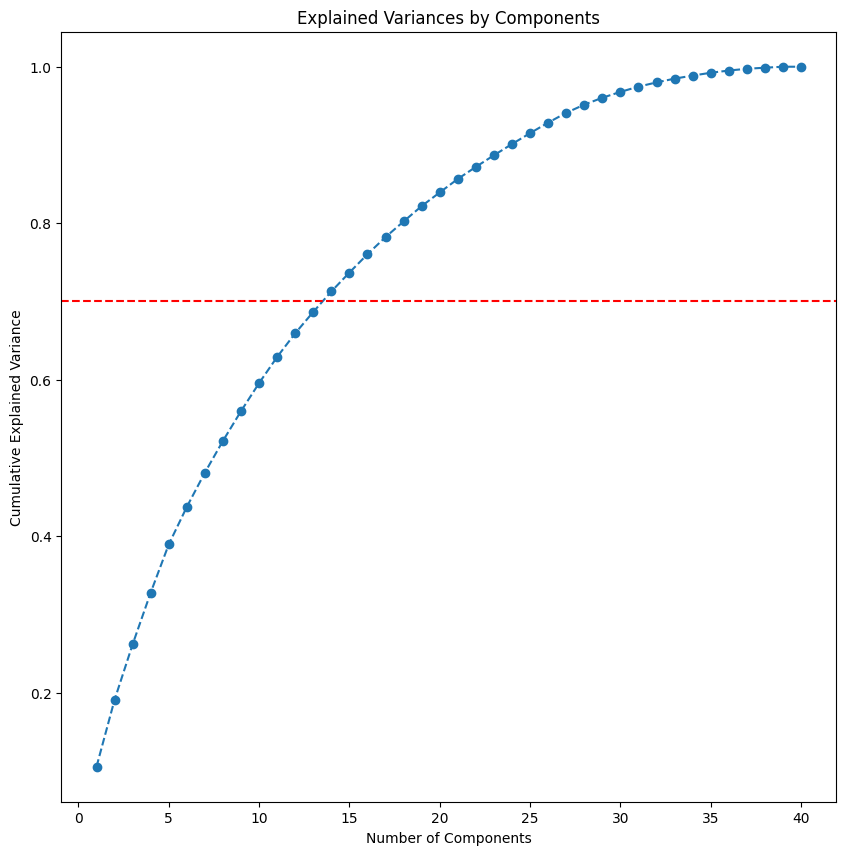

In [ ]:
# visualize the Explained Individual Components
import matplotlib.pyplot as plt
plt.figure(figsize = (10,10))
plt.plot(range(1,41), pca.explained_variance_ratio_.cumsum(), marker = 'o', linestyle = '--')
plt.title("Explained Variances by Components")
plt.axhline(y=0.7, color='r', linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

In [ ]:
# find the least number of components that can explain more than 70% variance
sum = 0
exp_var = pca.explained_variance_ratio_
for ix, i in enumerate(exp_var):
  sum = sum + i
  if(sum>0.70):
    print("Number of PCs that explain at least 70% variance: ", ix+1)
    break

Number of PCs that explain at least 70% variance:  14


In [ ]:
# creating 14 components
pc_comps = [f"PC{i}" for i in range(1, 15)]
data_pca = pd.DataFrame(np.round(pca.components_[:14,:],2),index=pc_comps,columns=X_train_scaled.columns)
exp_var = pca.explained_variance_ratio_
data_pca.T

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
home_1,0.13,-0.11,0.06,-0.01,0.06,-0.08,0.06,-0.06,0.35,0.03,-0.17,0.02,-0.12,0.05
home_2,0.09,-0.00,-0.18,0.10,0.04,-0.12,-0.12,-0.10,0.19,-0.07,-0.17,-0.13,0.23,-0.17
home_3,0.20,0.03,-0.07,0.16,-0.06,0.03,0.08,0.30,-0.13,-0.09,0.04,0.01,-0.03,0.03
visit_1,-0.16,-0.10,-0.04,0.13,0.06,-0.13,-0.03,0.05,-0.04,0.01,-0.01,0.14,-0.26,-0.22
visit_2,-0.08,-0.01,0.06,0.20,0.18,-0.22,-0.01,0.09,-0.09,-0.14,-0.09,0.03,0.07,0.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
visit_team_Providence,0.10,0.04,-0.03,0.10,-0.02,-0.10,-0.15,0.10,-0.01,-0.09,-0.08,-0.19,0.17,0.02
visit_team_Quinnipiac,0.02,-0.08,0.01,-0.05,0.24,-0.03,-0.05,-0.03,-0.12,-0.03,0.06,0.03,-0.22,0.40
visit_team_St. Cloud St.,-0.02,-0.03,0.10,-0.03,-0.01,0.06,-0.12,-0.00,0.01,-0.04,0.10,-0.04,0.13,0.11
visit_team_UConn,-0.01,0.04,0.05,0.01,0.06,-0.02,-0.06,-0.14,0.05,-0.03,-0.13,-0.10,0.08,0.07


In [ ]:
# fitting PCA into X
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
# list of all train features scaled
train_features_scaled = pd.DataFrame(X_train_pca)

In [ ]:
# getting the variance inflation scores for the features
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_series = pd.Series(
    [variance_inflation_factor(train_features_scaled.values, i) for i in range(train_features_scaled.shape[1])],
    index = train_features_scaled.columns,
    dtype = float)

print("VIF Scores: \n\n{}\n".format(vif_series))

VIF Scores: 

0     1.0
1     1.0
2     1.0
3     1.0
4     1.0
5     1.0
6     1.0
7     1.0
8     1.0
9     1.0
10    1.0
11    1.0
12    1.0
13    1.0
14    1.0
15    1.0
16    1.0
17    1.0
18    1.0
19    1.0
20    1.0
21    1.0
22    1.0
23    1.0
24    1.0
25    1.0
26    1.0
27    1.0
28    1.0
29    1.0
30    1.0
31    1.0
32    1.0
33    1.0
34    1.0
35    1.0
36    1.0
37    1.0
38    1.0
39    1.0
dtype: float64



#Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_pca, y_train)

LinearRegression()

In [ ]:
# Checking performance on the training data
model_perf = model_performance_regression(model, X_train_pca, y_train)
model_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,1.570485e-15,1.260103e-15,1.0,1.0,inf


In [ ]:
# Checking performance on the test data
model_perf = model_performance_regression(model, X_test_pca, y_test)
model_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.848421,0.704058,0.685669,1.091257,inf


##Regularization

In [ ]:
# ridge regression
from sklearn.linear_model import Ridge
ridge_model = Ridge() #creating Ridge Regression model
ridge_model.fit(X_train_pca, y_train) # Fitting the data into the model

Ridge()

In [ ]:
# checking performance on training data
ridge_reg = model_performance_regression(ridge_model, X_train_pca, y_train)
ridge_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.021396,0.015558,0.999837,1.006376,inf


In [ ]:
# checking peroformance on test data
ridge_reg = model_performance_regression(ridge_model, X_test_pca, y_test)
ridge_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.837003,0.688936,0.694072,1.088818,inf


In [ ]:
# optimizing the regularization parameter by penalizing larger coefficients
from sklearn.model_selection import KFold, GridSearchCV
folds = KFold(n_splits=10, shuffle=True, random_state=1)
params = {'alpha':[0.001, 0.01, 0.1, 0.2, 0.5, 0.9, 1, 5,10,20]}
model = Ridge()
model_cv = GridSearchCV(estimator=model, param_grid=params, scoring='r2', cv=folds, return_train_score=True)
model_cv.fit(X_train_pca,y_train)
model_cv.best_params_

{'alpha': 0.001}

In [ ]:
# tuned ridge regression model
ridge_model_tuned = Ridge(alpha=0.001)
ridge_model_tuned.fit(X_train_pca, y_train)

Ridge(alpha=0.001)

In [ ]:
# checking performance on training data
ridge_reg = model_performance_regression(ridge_model_tuned, X_train_pca, y_train)
ridge_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.000023,0.000017,1.0,1.0,inf


In [ ]:
# checking performance on test data
ridge_reg = model_performance_regression(ridge_model_tuned, X_test_pca, y_test)
ridge_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.848358,0.704004,0.685716,1.091244,inf


In [ ]:
# lasso regression
from sklearn.linear_model import Lasso
lasso_model = Lasso()
lasso_model.fit(X_train_pca, y_train)

Lasso()

In [ ]:
# checking performance on the training data
lasso_reg = model_performance_regression(lasso_model, X_train_pca, y_train)
lasso_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,1.120329,0.96041,0.551737,18.482258,inf


In [ ]:
# checking performance on the test data
lasso_reg = model_performance_regression(lasso_model, X_test_pca, y_test)
lasso_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,1.127472,1.006347,0.444894,1.16116,inf


In [ ]:
# optimizing the regularization parameter
folds = KFold(n_splits=10, shuffle=True, random_state=1)
params = {'alpha':[0.001, 0.01, 0.1, 0.2, 0.5, 0.9, 1, 5,10,20]}
model = Lasso()
model_cv = GridSearchCV(estimator=model, param_grid=params, scoring='r2', cv=folds, return_train_score=True)
model_cv.fit(X_train_pca,y_train)
model_cv.best_params_

{'alpha': 0.1}

In [ ]:
# tuned lasso
lasso_model_tuned = Lasso(alpha=0.001)
lasso_model_tuned.fit(X_train_pca, y_train)

Lasso(alpha=0.001)

In [ ]:
# checking performance on training data
lasso_reg = model_performance_regression(lasso_model_tuned, X_train_pca, y_train)
lasso_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.007876,0.006144,0.999978,1.000864,inf


In [ ]:
# checking performance on test data
lasso_reg = model_performance_regression(lasso_model_tuned, X_test_pca, y_test)
lasso_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.840731,0.69656,0.691341,1.089611,inf


In [ ]:
# elastic net
from sklearn.linear_model import ElasticNet
elastic_model = ElasticNet()
elastic_model.fit(X_train_pca, y_train)

ElasticNet()

In [ ]:
# checking performance on training data
elastic_reg = model_performance_regression(elastic_model, X_train_pca, y_train)
elastic_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.863169,0.714514,0.733907,11.377621,inf


In [ ]:
# checking performance on test data
elastic_reg = model_performance_regression(elastic_model, X_test_pca, y_test)
elastic_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.992157,0.863651,0.570142,1.124798,inf


In [ ]:
# optimizing elastic net
folds = KFold(n_splits=10, shuffle=True, random_state=1)
params = {'alpha':[0.001, 0.01, 0.1, 0.2, 0.5, 0.9],
         'l1_ratio': [0.001, 0.01, 0.02, 0.03, 0.04, 0.05]}
model = ElasticNet()
model_cv = GridSearchCV(estimator=model, param_grid=params, scoring='r2', cv=folds, return_train_score=True)
model_cv.fit(X_train_pca,y_train)
model_cv.best_params_

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.156e-02, tolerance: 9.875e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.194e-02, tolerance: 1.050e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.301e-02, tolerance: 9.875e

{'alpha': 0.01, 'l1_ratio': 0.001}

In [ ]:
# tuned elastic net
elastic_model_tuned = ElasticNet(alpha=0.01, l1_ratio=0.001)
elastic_model_tuned.fit(X_train_pca, y_train)


ElasticNet(alpha=0.01, l1_ratio=0.001)

In [ ]:
# checking performance on training data
elastic_reg = model_performance_regression(elastic_model_tuned, X_train_pca, y_train)
elastic_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.009067,0.006547,0.999971,1.001145,inf


In [ ]:
# checking performance on test data
elastic_reg = model_performance_regression(elastic_model_tuned, X_test_pca, y_test)
elastic_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.843178,0.697287,0.689542,1.090133,inf


# Decision Tree

In [ ]:
# creating decision tree
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(X_train_pca, y_train)

DecisionTreeRegressor()

In [ ]:
# checking performance on training data
dt_reg = model_performance_regression(dt, X_train_pca, y_train)
dt_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.0,0.0,1.0,1.0,0.0


In [ ]:
# checking performance on test data
dt_reg = model_performance_regression(dt, X_test_pca, y_test)
dt_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,1.095445,0.6,0.475983,1.152134,inf


In [ ]:
# grid search for best parameters for the decision tree
dt_tuned = DecisionTreeRegressor()

param_grid = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 10],
    'max_features': [None, 'sqrt', 'log2']
}

# grid search
grid_search = GridSearchCV(estimator=dt_tuned,
                           param_grid=param_grid,
                           scoring='neg_mean_squared_error',
                           cv=5,
                           n_jobs=-1,
                           verbose=1)

# Fit the grid search to the data
grid_search.fit(X_train_pca, y_train)

# Best parameters and score
best_params = grid_search.best_params_
best_score = -grid_search.best_score_  # Convert back to positive MSE

print("Best Parameters:", best_params)
print("Best Cross-Validated MSE:", best_score)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Best Parameters: {'criterion': 'poisson', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Cross-Validated MSE: 1.10767507558579


In [ ]:
# tuned decision tree
dt_tuned = DecisionTreeRegressor(criterion='poisson', max_depth=15, min_samples_leaf=2, min_samples_split=10)
dt_tuned.fit(X_train_pca, y_train)

DecisionTreeRegressor(criterion='poisson', max_depth=15, min_samples_leaf=2,
                      min_samples_split=10)

In [ ]:
# checking performance on training data
dt_reg = model_performance_regression(dt_tuned, X_train_pca, y_train)
dt_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.434613,0.261111,0.93254,3.630952,inf


In [ ]:
# checking performance on test data
dt_reg = model_performance_regression(dt_tuned, X_test_pca, y_test)
dt_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,1.08255,0.716667,0.488247,1.148573,inf


#Random Forest

In [ ]:
# creating random forest regressor
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_train_pca, y_train)

RandomForestRegressor()

In [ ]:
# checking performance on training data
rf_reg = model_performance_regression(rf, X_train_pca, y_train)
rf_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.388867,0.27775,0.945994,3.106244,inf


In [ ]:
# checking performance on test data
rf_reg = model_performance_regression(rf, X_test_pca, y_test)
rf_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,1.065528,0.799,0.504214,1.143938,inf


In [ ]:
# grid search for best parameters
"""
rf_regressor = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# grid search
grid_search = GridSearchCV(estimator=rf_regressor,
                           param_grid=param_grid,
                           scoring='neg_mean_squared_error',
                           cv=5,
                           n_jobs=-1,
                           verbose=1)

# Fit the grid search to the data
grid_search.fit(X_train_pca, y_train)

# Best parameters and score
best_params = grid_search.best_params_
best_score = -grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Cross-Validated MSE:", best_score)
"""

'\nrf_regressor = RandomForestRegressor(random_state=42)\n\nparam_grid = {\n    \'n_estimators\': [50, 100, 200],\n    \'max_depth\': [None, 10, 20, 30],\n    \'min_samples_split\': [2, 5, 10],\n    \'min_samples_leaf\': [1, 2, 4],\n    \'max_features\': [\'sqrt\', \'log2\']\n}\n\n# grid search\ngrid_search = GridSearchCV(estimator=rf_regressor,\n                           param_grid=param_grid,\n                           scoring=\'neg_mean_squared_error\',\n                           cv=5,\n                           n_jobs=-1,\n                           verbose=1)\n\n# Fit the grid search to the data\ngrid_search.fit(X_train_pca, y_train)\n\n# Best parameters and score\nbest_params = grid_search.best_params_\nbest_score = -grid_search.best_score_\n\nprint("Best Parameters:", best_params)\nprint("Best Cross-Validated MSE:", best_score)\n'

In [ ]:
# tuned rf
rf_tuned = RandomForestRegressor(n_estimators=50, min_samples_split=5, min_samples_leaf=1, max_features='sqrt', max_depth=None)
rf_tuned.fit(X_train_pca, y_train)

RandomForestRegressor(max_features='sqrt', min_samples_split=5, n_estimators=50)

In [ ]:
# checking performance on training data
rf_reg = model_performance_regression(rf_tuned, X_train_pca, y_train)
rf_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.686027,0.598911,0.831917,7.555251,inf


In [ ]:
# checking performance on test data
rf_reg = model_performance_regression(rf_tuned, X_test_pca, y_test)
rf_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,1.412138,1.202071,0.129199,1.252813,inf


#Gradient Boosting

In [ ]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor()
gbr.fit(X_train_pca,y_train)

GradientBoostingRegressor()

In [ ]:
# checking performance on training data
gbr_reg = model_performance_regression(gbr, X_train_pca, y_train)
gbr_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.001112,0.000898,1.0,1.000017,inf


In [ ]:
# checking performance on test data
gbr_reg = model_performance_regression(gbr, X_test_pca, y_test)
gbr_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,1.180743,0.981746,0.391199,1.176749,inf


In [ ]:
# grid search
gb_model = GradientBoostingRegressor()

param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

grid_search = GridSearchCV(estimator=gb_model,
                           param_grid=param_grid,
                           scoring='neg_mean_squared_error',
                           cv=5,
                           verbose=2, n_jobs=-1)

"""

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = -grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Cross-Validated MSE:", best_score)
"""

'\n\ngrid_search.fit(X_train, y_train)\n\nbest_params = grid_search.best_params_\nbest_score = -grid_search.best_score_\n\nprint("Best Parameters:", best_params)\nprint("Best Cross-Validated MSE:", best_score)\n'

In [ ]:
# tuned gradient boosting
gb_tuned = GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, max_depth=7, min_samples_leaf=4, min_samples_split=5)
gb_tuned.fit(X_train_pca, y_train)


GradientBoostingRegressor(max_depth=7, min_samples_leaf=4, min_samples_split=5,
                          n_estimators=50)

In [ ]:
# checking performance on training data
gb_reg = model_performance_regression(gb_tuned, X_train_pca, y_train)
gb_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.104531,0.044596,0.996098,1.152195,inf


In [ ]:
# checking performance on test data
gb_reg = model_performance_regression(gb_tuned, X_test_pca, y_test)
gb_reg

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,1.050746,0.845405,0.517875,1.139972,inf


#Predict Goals Scored

In [ ]:
# Example of how to set up the required variables
train_features = X_train.columns.tolist()  # These should be the exact columns used during training
print(f"Number of training features: {len(train_features)}")
print(f"First few features: {train_features[:5]}")

Number of training features: 87
First few features: ['home_1', 'home_2', 'home_3', 'visit_1', 'visit_2']


In [ ]:
def predict_goals(away_name, home_name):
    try:
        model = lasso_model_tuned

        # # Check if the teams are in the data
        # home_team_col = f'home_team_{home_name}'
        # away_team_col = f'visit_team_{away_name}'

        # home_not_found = home_team_col not in df_new.columns
        # away_not_found = away_team_col not in df_new.columns

        # # Setting up the new DataFrames and handling if the data was not found
        # df_home = df_new[df_new[home_team_col] == 1] if not home_not_found else pd.DataFrame()
        # df_away = df_new[df_new[away_team_col] == 1] if not away_not_found else pd.DataFrame()

        df_home = df_new[df_new["home_team"] == home_name]
        df_away = df_new[df_new["visit_team"] == away_name]

        # Feature names from the model
        feature_names = train_features

        # Splitting feature names into home and away features
        home_features = [f for f in feature_names if f.startswith('home_')]
        away_features = [f for f in feature_names if f.startswith('visit_')]

        # Calculate averages for all features
        numeric_cols = df_new.select_dtypes(include='number').columns
        averages = df_new[numeric_cols].mean().to_dict()

        # Home stats
        home_stats = [
            df_home[col].iloc[-1] if col in df_home.columns else averages.get(col, 0)
            for col in home_features
        ]

        # Away stats
        away_stats = [
            df_away[col].iloc[-1] if col in df_away.columns else averages.get(col, 0)
            for col in away_features
        ]

        # Combine the stats into a single list for prediction
        new_stats = away_stats + home_stats

        # Create a DataFrame for the new game data
        df_predict = pd.DataFrame([new_stats], columns=feature_names)

        # Scale data
        df_predict_scaled = scaler.transform(df_predict)

        # Run PCA
        df_predict_pca = pca.transform(df_predict_scaled)

        # Predict the number of goals scored
        predicted_goals = model.predict(df_predict_pca)

        print(predicted_goals)

        # Ensure the predicted goals are non-negative
        predicted_goals = max(0, predicted_goals[0])

        # Round to the nearest integer
        predicted_goals = round(predicted_goals)

        # Number of goals scored
        goals = predicted_goals

        return f'The home team ({home_name}) will score {goals} goals'

    except Exception as e:
        return f"Unable to predict the game due to an error: {str(e)}"


In [ ]:
predict_goals("New Hampshire", "Northeastern")

[9.99621409]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


'The home team (Northeastern) will score 10 goals'

In [ ]:
predict_goals("Northeastern", "Boston University")

[-4.07002882e+08]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


'The home team (Boston University) will score 0 goals'

In [ ]:
predict_goals("Northeastern", "Penn St.")

[-4.07002885e+08]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


'The home team (Penn St.) will score 0 goals'